# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import string
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words

# Load the data. The CSV has no header row, so we name the columns ourselves.
df = pd.read_csv(
    'twitter_training.csv',
    header=None,
    names=['Tweet ID', 'Entity', 'Sentiment', 'Tweet']
)

# A small number of tweets are missing text — drop those.
df = df.dropna(subset=['Tweet']).reset_index(drop=True)
df.head()

,Tweet ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


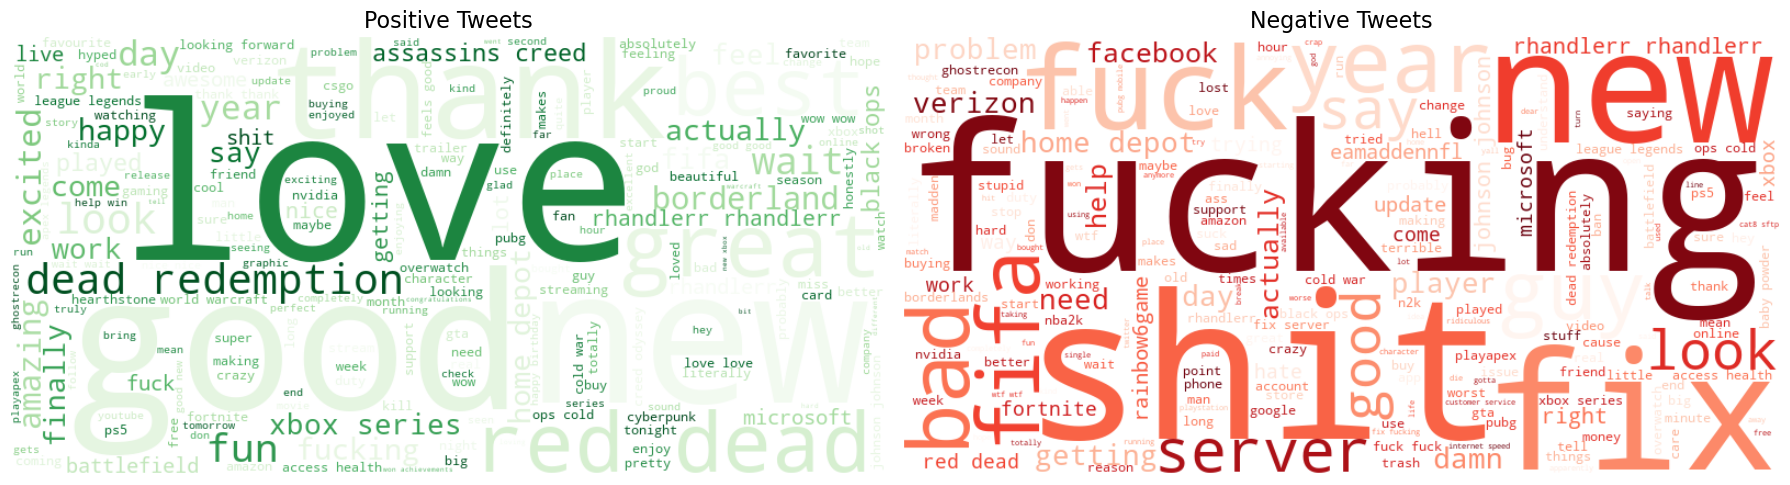

In [3]:
additional_stopwords = {
    'im', 'game', 'games', 'just', 'like', 'get', 'got', 'dont',
    'know', 'think', 'really', 'going', 'amp', 'one', 'go', 'make',
    'want', 'thing', 'people', 'time', 'play', 'playing', 'today',
    'still', 'now', 'http', 'https', 'co', 'rt', 'lol', 'yeah',
    'gonna', 'thats', 'wanna', 'didnt', 'doesnt', 'cant', 'isnt'
}

def clean_words(text_blob):
    """Lowercase, tokenize, strip punctuation, drop stopwords and short tokens."""
    words = text_blob.lower().split()
    return [
        w.strip(string.punctuation) for w in words
        if w.isalnum()
        and w not in sklearn_stop_words
        and w not in additional_stopwords
        and len(w) > 2
    ]

# Combine all positive and all negative tweets into single big strings
positive_blob = ' '.join(df[df['Sentiment'] == 'Positive']['Tweet'].astype(str))
negative_blob = ' '.join(df[df['Sentiment'] == 'Negative']['Tweet'].astype(str))

positive_words = clean_words(positive_blob)
negative_words = clean_words(negative_blob)

# Generate the two word clouds side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens').generate(' '.join(positive_words))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Tweets', fontsize=16)
axes[0].axis('off')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds').generate(' '.join(negative_words))
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Tweets', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()


These are two word clouds for the positive and negative tweets. In hindsight I probably could have picked a dataset that used more professional language because this should have been an obvious outcome.

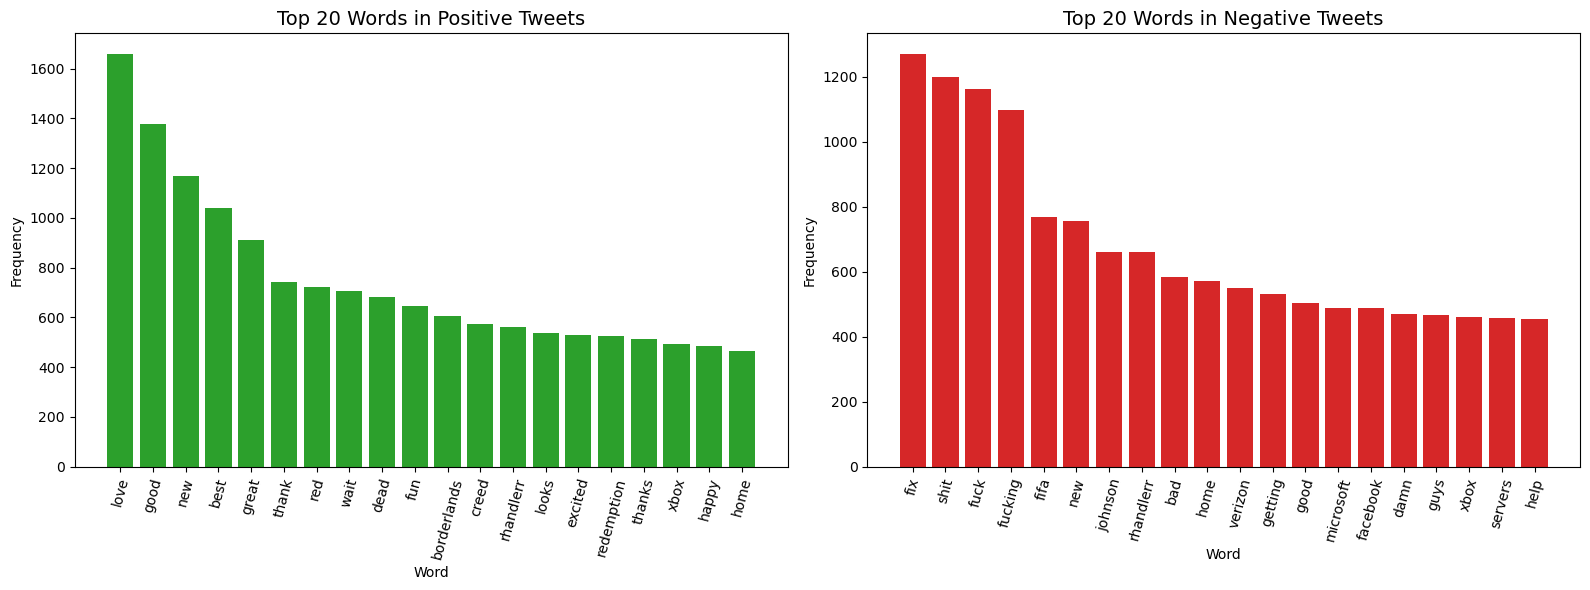

In [4]:
positive_top20 = pd.DataFrame(
    Counter(positive_words).most_common(20),
    columns=['Word', 'Frequency']
)
negative_top20 = pd.DataFrame(
    Counter(negative_words).most_common(20),
    columns=['Word', 'Frequency']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(positive_top20['Word'], positive_top20['Frequency'], color='#2ca02c')
axes[0].set_title('Top 20 Words in Positive Tweets', fontsize=14)
axes[0].set_xlabel('Word')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=75)

axes[1].bar(negative_top20['Word'], negative_top20['Frequency'], color='#d62728')
axes[1].set_title('Top 20 Words in Negative Tweets', fontsize=14)
axes[1].set_xlabel('Word')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

These are two word frequency charts for positive and negative tweets. I'm a bit surprised by how much less professional the negative tweets are in terms of language but I assume the negatice emotions have a stronger emotion attached to them which leads to people using these words as adjectives.

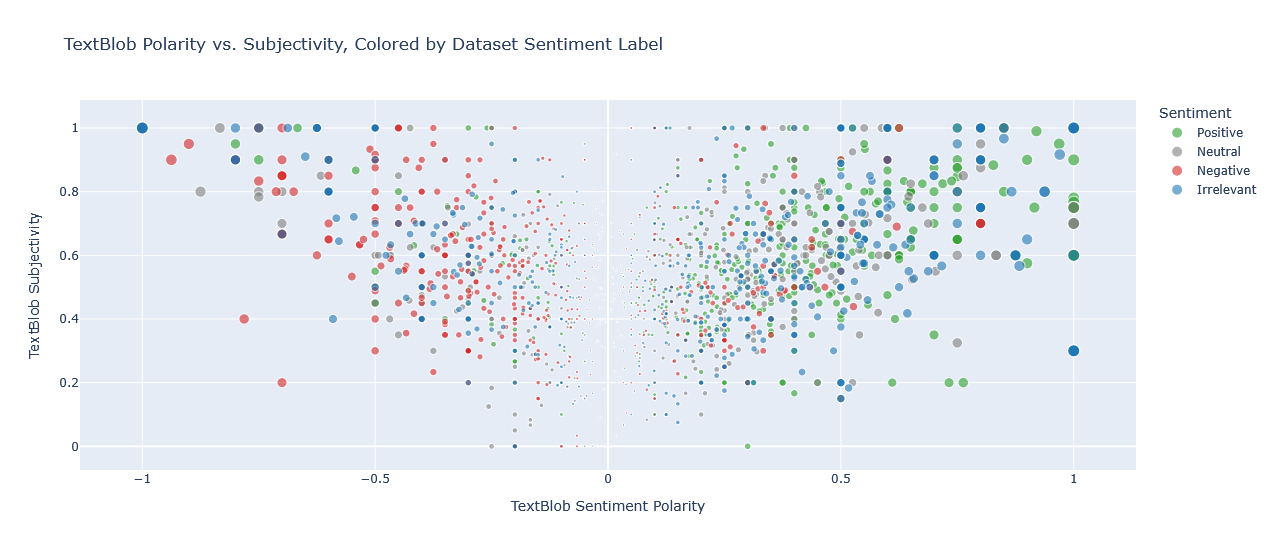

In [7]:
from textblob import TextBlob
import plotly.express as px

# Sample 3,000 tweets stratified by sentiment so all classes are visible
sample = pd.concat([
    df[df['Sentiment'] == s].sample(min(750, (df['Sentiment'] == s).sum()), random_state=42)
    for s in df['Sentiment'].unique()
]).reset_index(drop=True)

sample['polarity'] = sample['Tweet'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
sample['subjectivity'] = sample['Tweet'].apply(lambda t: TextBlob(str(t)).sentiment.subjectivity)
sample['abs_polarity'] = sample['polarity'].abs()

fig = px.scatter(
    sample,
    x='polarity',
    y='subjectivity',
    color='Sentiment',
    size='abs_polarity',
    size_max=12,
    opacity=0.6,
    hover_data={'Entity': True, 'Tweet': True,
                'polarity': ':.2f', 'subjectivity': ':.2f',
                'abs_polarity': False},
    color_discrete_map={
        'Positive': '#2ca02c', 'Negative': '#d62728',
        'Neutral': '#7f7f7f', 'Irrelevant': '#1f77b4'
    },
    labels={'polarity': 'TextBlob Sentiment Polarity',
            'subjectivity': 'TextBlob Subjectivity'},
    title='TextBlob Polarity vs. Subjectivity, Colored by Dataset Sentiment Label'
)
fig.update_layout(height=550)
fig.show()

this is a textblob that samples 750 tweets from each of the sentiment classes since it would be unreasonable to load this with 70k data points. I think it's interesting to see how there isn't much of noticable correlation between each of the sentiments and where it is on the chart.